In [26]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("patrickb1912/ipl-complete-dataset-20082020")
deliveries = pd.read_csv(os.path.join(path, "deliveries.csv"), nrows=50000)
matches = pd.read_csv(os.path.join(path, "matches.csv"), nrows=50000)
df= deliveries



Q1 — Most Runs

In [8]:
most_runs= df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).reset_index()
most_runs.columns = ['Batsman_name','total_runs']
print(most_runs.head(5))


   Batsman_name  total_runs
0      SK Raina        1536
1  SR Tendulkar        1446
2  AC Gilchrist        1397
3     JH Kallis        1376
4     RG Sharma        1373


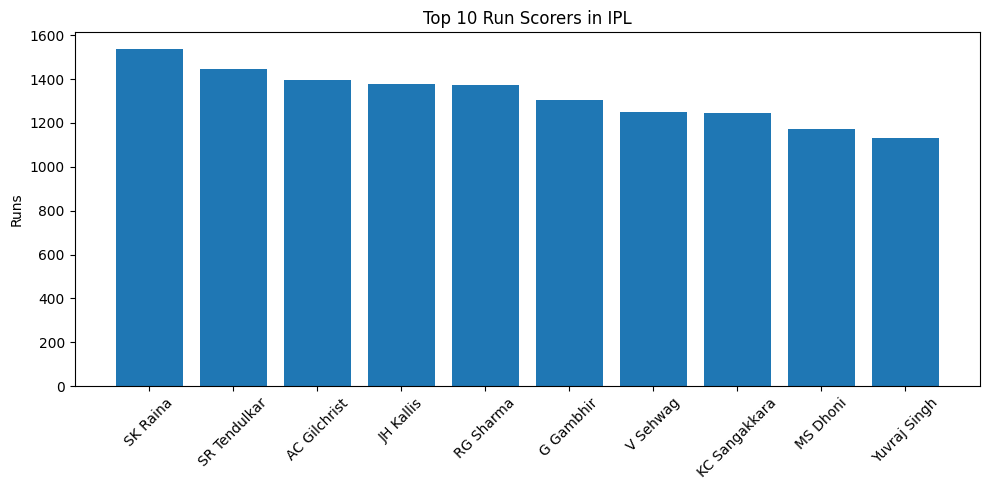

In [9]:
top10 = most_runs.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Batsman_name'], top10['total_runs'])
plt.xticks(rotation=45)
plt.title("Top 10 Run Scorers in IPL")
plt.ylabel("Runs")
plt.tight_layout()
plt.savefig("top_run_scorers.png")
plt.show()

Insight: Sk Raina(Suresh Raina) is the most consistent run scorer in the sampled IPL data. His volume suggests he batted in high pressure middle order positions across multiple seasons rather than one standout year.

Q2 — Most Wickets

In [10]:
most_wickets =df.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).reset_index()
most_wickets.columns = ['Bowler', 'Total_wickets']
print(most_wickets.head(5))

      Bowler  Total_wickets
0  IK Pathan             64
1   RP Singh             63
2  JA Morkel             57
3    PP Ojha             56
4   SK Warne             56


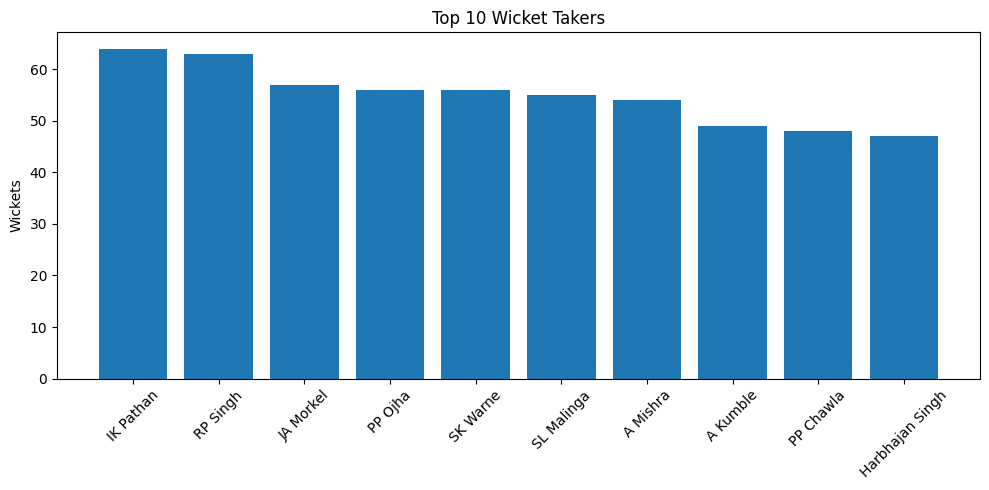

In [11]:
top10 = most_wickets.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Bowler'], top10['Total_wickets'])
plt.xticks(rotation=45)
plt.title("Top 10 Wicket Takers")
plt.ylabel("Wickets")
plt.tight_layout()
plt.savefig("top_wicket_takers.png")
plt.show()

Insight: K Pathan leads with 64 wickets in the sampled data, closely followed by RP Singh with 63 with both consistently taking wickets across multiple seasons rather than peaking in one.

Q3 — Most Dot Balls

In [12]:
most_dots = df[df['total_runs'] == 0].groupby('bowler').size().sort_values(ascending=False).reset_index()
most_dots.columns = ['Bowler', 'Dot_balls']
most_dots.head(5)


,Bowler,Dot_balls
0,RP Singh,462
1,IK Pathan,444
2,M Muralitharan,431
3,DW Steyn,390
4,SK Warne,387


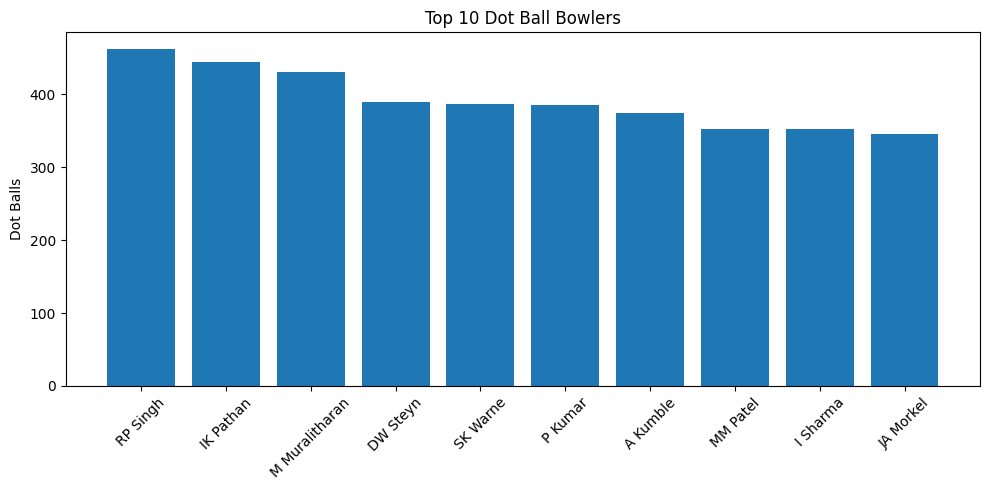

In [19]:
top10 = most_dots.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Bowler'], top10['Dot_balls'])
plt.xticks(rotation=45)
plt.title("Top 10 Dot Ball Bowlers")
plt.ylabel("Dot Balls")
plt.tight_layout()
plt.savefig("dot_balls.png")
plt.show()

Insight: RP Singh bowled the most dot balls (462) in the sample. Combined with his second place wicket tally, this confirms he was IPL's most economical as well as a threatening bowler and suffocating batters while consistently taking wickets.

Q4 — Most POTM awards 

In [13]:
potms = matches.groupby('player_of_match').size().sort_values(ascending=False).reset_index().head(5)
potms.columns = ['most POTM', 'POTM count']
potms

,most POTM,POTM count
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,DA Warner,18
4,V Kohli,18


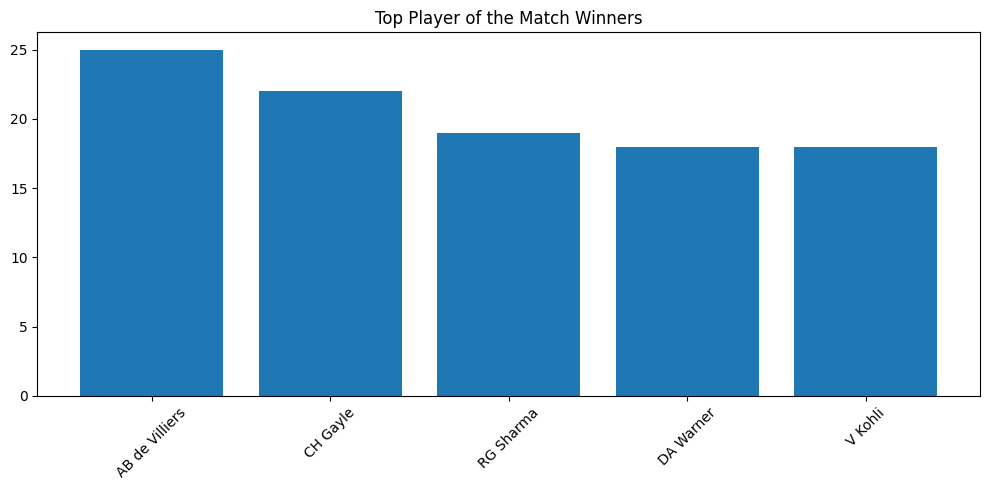

In [20]:
plt.figure(figsize=(10,5))
plt.bar(potms['most POTM'], potms['POTM count'])
plt.xticks(rotation=45)
plt.title("Top Player of the Match Winners")
plt.tight_layout()
plt.savefig("potm_awards.png")
plt.show()

Insight: AB de Villiers leads IPL Player of the Match awards with 25, followed by CH Gayle with 22 and RG Sharma with 19. All top 5 are batsmen, suggesting match winning innings are valued more than bowling performances in IPL.

Q5 — Which team won the most matches across all seasons?


In [14]:
most_wins = matches.groupby('winner').size().reset_index()
most_wins.columns = ['Team name', 'Total Wins']
most_wins= most_wins.sort_values(by='Total Wins',ascending=False)
print(most_wins.head(5))

                      Team name  Total Wins
10               Mumbai Indians         144
0           Chennai Super Kings         138
8         Kolkata Knight Riders         131
16  Royal Challengers Bangalore         116
13             Rajasthan Royals         112


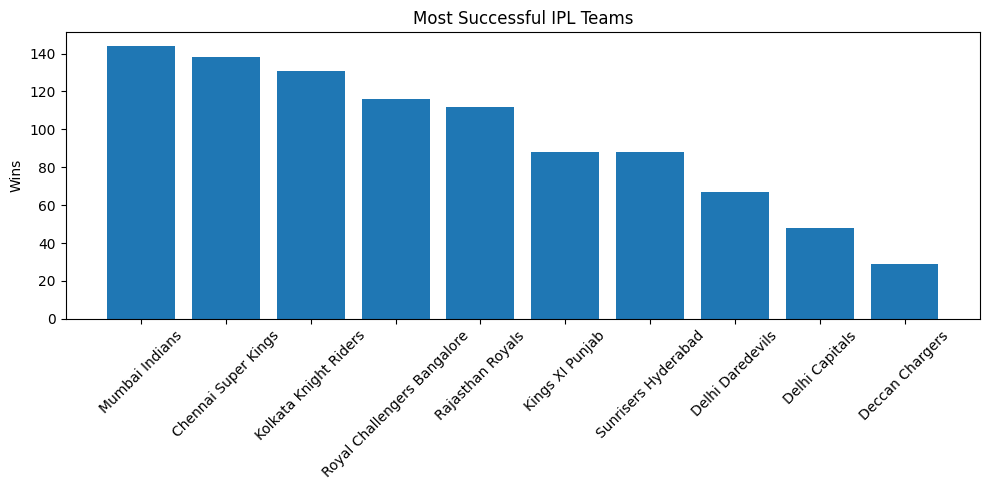

In [21]:
top10 = most_wins.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Team name'], top10['Total Wins'])
plt.xticks(rotation=45)
plt.title("Most Successful IPL Teams")
plt.ylabel("Wins")
plt.tight_layout()
plt.savefig("team_wins.png")
plt.show()

Insights: Mumbai Indians lead with 144 wins which is suggesting their success is built on team depth and consistency rather than relying on one match winner.

Q6 — Which batsman hits the most sixes?


In [15]:
most_sixes = df[df['batsman_runs'] == 6].groupby(by='batter').size().reset_index()
most_sixes.columns = ['Batsman Name','Total sixes']
most_sixes = most_sixes.sort_values(by='Total sixes',ascending=False)
most_sixes.head(5)

,Batsman Name,Total sixes
9,AC Gilchrist,70
171,YK Pathan,68
140,SK Raina,66
173,Yuvraj Singh,62
117,RG Sharma,60


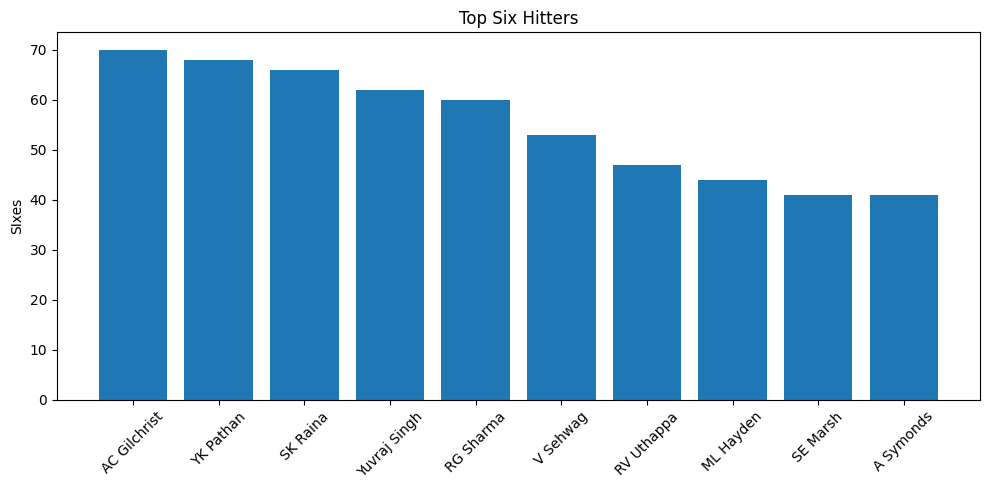

In [24]:
top10 = most_sixes.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Batsman Name'], top10['Total sixes'])
plt.xticks(rotation=45)
plt.title('Top Six Hitters')
plt.ylabel('SIxes')
plt.tight_layout()
plt.savefig('Most_sixes.png')
plt.show()

Insight: While Adam Gilchrist and Yusuf Pathan top the list for total sixes, this metric is influenced by career longevity and batting position, suggesting that it reflects opportunity as much as hitting ability.

Q7 — Who has faced the most balls?

In [16]:
most_balls = df[df['extras_type'] != 'wides']
most_balls = df.groupby('batter').size().sort_values(ascending=False).reset_index(name = 'Balls faced')
most_balls.head(5)

,batter,Balls faced
0,JH Kallis,1276
1,SR Tendulkar,1247
2,SK Raina,1130
3,G Gambhir,1069
4,RG Sharma,1065


Insights: Among bowlers with 120+ balls, R Ashwin and SL Malinga in the top 5 confirms their reputation as the most economical bowlers in IPL history.

Q8 — best economy rate. Least runs per ball bowled

In [17]:
runs_conc = df.groupby('bowler')['total_runs'].sum().sort_values(ascending=False)
runs_conc.head(5)

balls_bowled = df.groupby('bowler').size().sort_values(ascending=False)
qualified = balls_bowled[balls_bowled >= 120].index
balls_bowled.head(5)

economy = (runs_conc/balls_bowled)[qualified].reset_index()
economy.columns = ['Bowler', 'economy']
economy = economy.sort_values(by='economy', ascending=True)
economy.head(5)

,Bowler,economy
68,A Singh,1.013158
61,Sohail Tanvir,1.037736
33,R Ashwin,1.044625
90,J Botha,1.052326
14,SL Malinga,1.065271


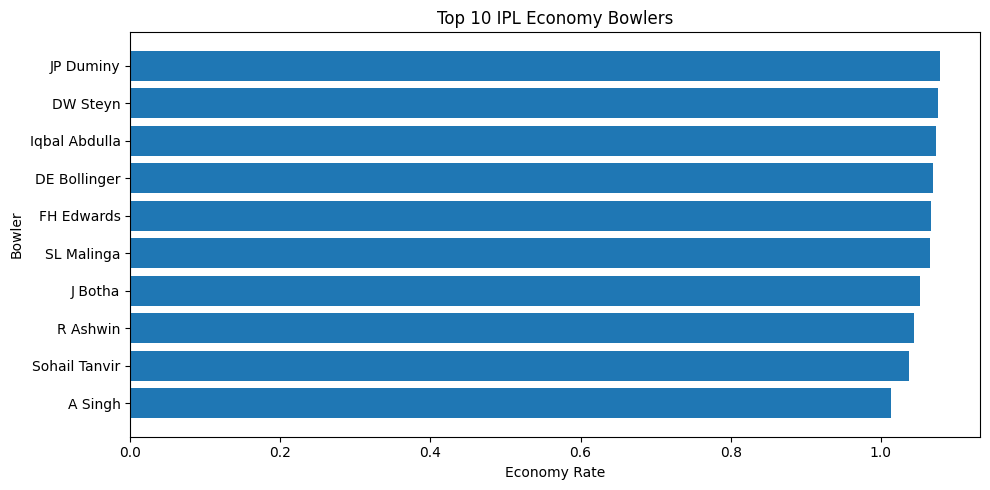

In [31]:
top10 = economy.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10['Bowler'], top10['economy'])

plt.title("Top 10 IPL Economy Bowlers")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

plt.tight_layout()

plt.savefig("economy_rate.png")

plt.show()

Insights: Among bowlers with 120+ balls bowled, A Singh and Sohail Tanvir lead in economy rate with conceding just over 1 run per ball. R Ashwin and SL Malinga in the top 5 confirms their reputation as the most economical bowlers in IPL history.

 Q9 — Six hitting rate

In [18]:
qualified_batters = most_balls[most_balls['Balls faced'] >= 200].set_index('batter')['Balls faced']
sixes = most_sixes.set_index('Batsman Name')['Total sixes']

six_rate = (sixes / qualified_batters).dropna().reset_index()
six_rate.columns = ['Batter', 'Six Rate']
six_rate = six_rate.sort_values(by='Six Rate', ascending=False)
print(six_rate.head(5))

         Batter  Six Rate
67    YK Pathan  0.094313
15     DR Smith  0.085000
8      CH Gayle  0.083885
20    JA Morkel  0.081081
29  LRPL Taylor  0.078431


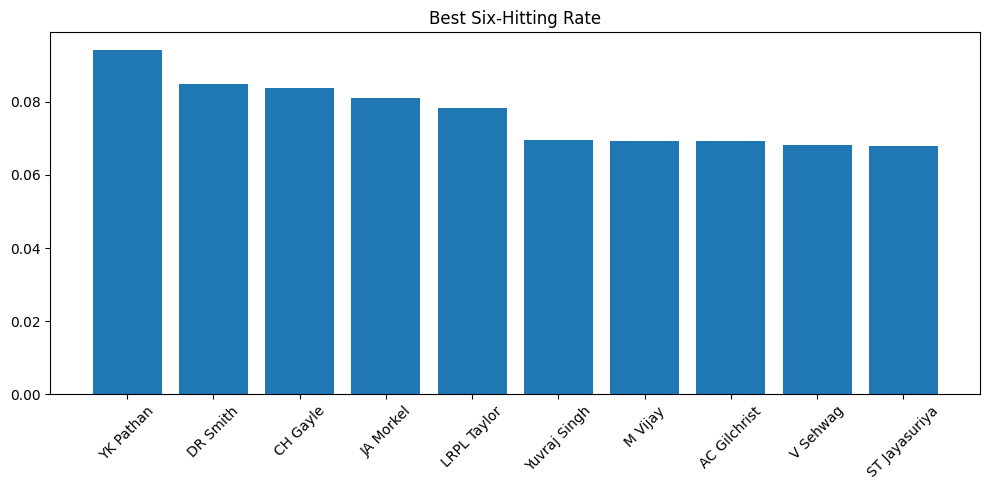

In [32]:
top10 = six_rate.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Batter'], top10['Six Rate'])
plt.xticks(rotation=45)
plt.title("Best Six-Hitting Rate")
plt.tight_layout()
plt.savefig("six_hitting_rate.png")
plt.show()

Insights: Yusuf Pathan hits a six every 10 balls, with CH Gayle in third place confirming his reputation as the most destructive hitter in IPL history.

In [30]:
economy.head()
economy.info()

<class 'pandas.DataFrame'>
Index: 109 entries, 68 to 106
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bowler   109 non-null    str    
 1   economy  109 non-null    float64
dtypes: float64(1), str(1)
memory usage: 2.6 KB
